# Should you really sell your stocks every May? 🍂
### The Halloween indicator — half folklore, half true, and a cash-in-summer timer that loses you money either way

![Signal: Weak](https://img.shields.io/badge/Signal-Weak-dab617?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Bad autumns?: Confirmed](https://img.shields.io/badge/Bad_autumns%3F-Confirmed-8b949e?style=flat-square)

*"Sell in May and go away"* is maybe the most-repeated line in market folklore: hold stocks November through April, sit in cash May through October, and you'll beat the market with less risk. It even has an academic paper behind it — Bouman & Jacobsen (2002) found the winter half beats the summer half in 36 of 37 countries they studied.

So is it true? Yes — mostly. Should you trade it? No. This is the story of how both of those can be true at once.

> 📓 **Plain-language layer.** Want the *t*-stats, the bootstrap and the cost math? See **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> ⚠️ **Method note.** ^GSPC 1950→2026 (price-only, matching the deep-history literature), SPY 1993→2026 and ^SP500TR 1988→2026 (both dividend-inclusive), yfinance, cached. Every chart is drawn by the code beside it; house style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from sell_in_may import data, strategy as st

HAVE_REAL = data.have_real()
if HAVE_REAL:
    MM = data.load_monthly()
else:
    MM = None
print("real cache present:", HAVE_REAL, "| monthly series:",
      (None if MM is None else {k: len(v) for k, v in MM.items()}))

# frozen headline numbers (mirror of docs/results.md)
R = {'as_of': '2026-06-30', 'fp_gspc': 'f17f1fc81bc9', 'fp_spy': '8324508d6a89', 'fp_tr': '02c7f8f5728e', 'fp_irx': '20827eb9627f', 'gspc': {'n_w': 459, 'n_s': 458, 'winter': 1.048, 'summer': 0.278, 'gap': 0.77, 'winter_half': 6.49, 'summer_half': 1.68, 'welch': 2.78, 'nw': 2.96}, 'sp500tr': {'n_w': 231, 'n_s': 230, 'winter': 1.168, 'summer': 0.643, 'gap': 0.526, 'winter_half': 7.26, 'summer_half': 3.93, 'welch': 1.33, 'nw': 1.42}, 'spy': {'n_w': 200, 'n_s': 200, 'winter': 1.092, 'summer': 0.619, 'gap': 0.473, 'winter_half': 6.77, 'summer_half': 3.78, 'welch': 1.1, 'nw': 1.18}, 'yb_gspc': {'n': 76, 'k': 47, 'hit': 61.8, 'wlo': 50.6, 'whi': 71.9, 'signp': 0.0505, 'mean': 4.64, 't': 3.16, 'lo': 1.78, 'hi': 7.56, 'ple0': 0.0006}, 'yb_tr': {'n': 38, 'k': 23, 'hit': 60.5, 'wlo': 44.7, 'whi': 74.4, 'signp': 0.2559, 'mean': 3.26, 't': 1.61, 'lo': -0.69, 'hi': 7.17, 'ple0': 0.0542}, 'yb_spy': {'n': 33, 'k': 19, 'hit': 57.6, 'wlo': 40.8, 'whi': 72.8, 'signp': 0.4869, 'mean': 3.0, 't': 1.41, 'lo': -1.08, 'hi': 7.08, 'ple0': 0.0765}, 'by_month': {'Jan': 0.96, 'Feb': -0.1, 'Mar': 0.89, 'Apr': 1.45, 'May': 0.37, 'Jun': 0.12, 'Jul': 1.22, 'Aug': -0.06, 'Sep': -0.73, 'Oct': 0.74, 'Nov': 1.76, 'Dec': 1.35}, 'bad_full_gap': 0.77, 'bad_full_t': 2.78, 'bad_trim_gap': 0.496, 'bad_trim_t': 1.88, 'bad_n_dropped': 10, 'bad_n_total': 917, 'bad_dates': ['1974-09', '1978-10', '1979-10', '1986-09', '1987-10', '2002-09', '2008-09', '2008-10', '2018-10', '2022-09'], 'timer_tr': {5: (8.06, 10.23, 0.52, 0.54, -31.7, -53.2), 10: (7.85, 10.23, 0.5, 0.54, -31.9, -53.2)}, 'timer_spy': {5: (7.28, 9.54, 0.49, 0.52, -31.5, -53.0), 10: (7.07, 9.54, 0.47, 0.52, -31.7, -53.0)}, 'timer_gspc': {5: (7.62, 6.31, 0.35, 0.19, -33.2, -56.9), 10: (7.41, 6.31, 0.33, 0.19, -33.4, -56.9)}, 'timer_years_tr': 38.4, 'timer_years_spy': 33.3, 'timer_years_gspc': 66.5, 'reverse_cagr': 4.64, 'reverse_bh_cagr': 10.23, 'reverse_sharpe': 0.2, 'syn_null_mean': -0.01, 'syn_null_sd': 1.04, 'syn_null_fire': 1, 'syn_planted_t': 2.38}


real cache present: True | monthly series: {'gspc': 917, 'spy': 400, 'sp500tr': 461, 'irx_pct': 798}


## The answer first

| Question | Answer |
|---|---|
| Does winter really beat summer? | **Yes, on average, everywhere we look.** Over 76 years of deep history the gap is **+0.77 points a month** (winter ~6.5% per half-year vs summer ~1.7%). |
| Is that a *statistical fact* or *could be luck*? | **Depends which tape.** The 76-year price-only tape clears our significance bar comfortably. The 33-38 year *dividend-inclusive* tapes — the ones that describe what you'd actually earn — don't quite get there. Direction agrees; certainty doesn't. |
| Is "summer is dead money" true? | **No — that's the catch.** Summer's average return is **positive** on every tape we tested (+0.62%/mo on SPY, roughly +3.8% every six months). It's just smaller than winter's, not zero. |
| So can you trade it? | **Not profitably.** A timer that holds cash all summer *loses* to buy-and-hold, in both raw return and risk-adjusted terms, because it's giving up a season that pays positive money. |

> The seasonal is real-ish. The trade isn't.

## 1 · The claim

> *"November through April is where the stock market does its work. May through October you're better off in cash — the risk isn't worth the (near-zero) reward."*

This isn't a fringe idea. Bouman & Jacobsen published it in the *American Economic Review* in 2002, and follow-up work has traced the pattern back to 1693 in UK data. It's one of the most studied, most repeated calendar effects in finance — which makes it a perfect test case: is the famous version of the story still true once you hold it to the desk's bar?

## 2 · So what?

If "sell in May" is real *and* tradable, it's one of the simplest edges imaginable: two trades a year, no forecasting, no data mining — just a calendar. Every discount brokerage account could run it. That's exactly why it's worth checking carefully: an edge this famous and this cheap to implement should have been arbitraged away years ago if it were genuinely free money. So we ask three things: is the pattern real, how much of it is a few scary autumns doing all the work, and does the obvious trade actually pay you after you account for the fact that summer isn't actually negative?

## 3 · How would we even know?

- **The split.** Every calendar month since 1950 sorted into "winter" (Nov–Apr) or "summer" (May–Oct) — a fixed, public rule; no fitting.
- **Three tapes, not one.** The deep ^GSPC history (price-only, since dividends aren't tracked that far back) *and* two modern dividend-inclusive tapes (SPY, ^SP500TR) — if they disagree, that itself is the finding.
- **The pairing check.** One (summer, winter) score per year for ~76 years, resampled at the *year* level so we never accidentally split a season in half.
- **The autopsy.** How much of the gap survives if we remove the ten worst individual Septembers/Octobers?
- **The trade check.** Buy stocks Nov 1, sell May 1 into cash (a real T-bill rate), buy back Nov 1 — versus just holding stocks the whole time, both compared on the *same* risk-adjusted basis.

## 4 · The teardown — let's actually look

**First, the headline.** Average monthly return, winter vs summer, on three different tapes.

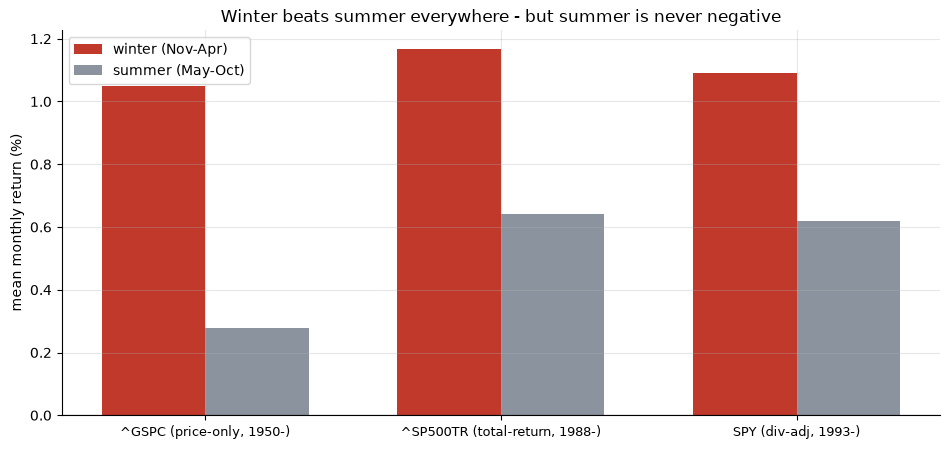

[('^GSPC (price-only, 1950-)', 1.0481718783993954, 0.27845280862089117), ('^SP500TR (total-return, 1988-)', 1.1683389400206805, 0.6425319020171939), ('SPY (div-adj, 1993-)', 1.0921547525433744, 0.6190365112050162)]


In [2]:
if HAVE_REAL:
    tags = {'gspc': '^GSPC (price-only, 1950-)', 'sp500tr': '^SP500TR (total-return, 1988-)',
            'spy': 'SPY (div-adj, 1993-)'}
    stats = {k: st.headline_split(MM[k]) for k in tags if k in MM}
    labels = list(tags[k] for k in stats)
    winters = [stats[k]['winter_pct'] for k in stats]
    summers = [stats[k]['summer_pct'] for k in stats]
else:
    labels = ['^GSPC (price-only, 1950-)', '^SP500TR (total-return, 1988-)', 'SPY (div-adj, 1993-)']
    winters = [R['gspc']['winter'], R['sp500tr']['winter'], R['spy']['winter']]
    summers = [R['gspc']['summer'], R['sp500tr']['summer'], R['spy']['summer']]
x = np.arange(len(labels)); w = 0.35
fig, ax = plt.subplots(figsize=(9.6, 4.6))
ax.bar(x - w/2, winters, w, color=RED, label='winter (Nov-Apr)')
ax.bar(x + w/2, summers, w, color=GREY, label='summer (May-Oct)')
ax.set_xticks(x); ax.set_xticklabels(labels, fontsize=9)
ax.axhline(0, c='k', lw=.8)
ax.set_ylabel('mean monthly return (%)')
ax.set_title('Winter beats summer everywhere - but summer is never negative')
ax.legend(); plt.tight_layout(); plt.show()
print(list(zip(labels, winters, summers)))

Winter beats summer on **every** tape — but look at the grey bars: summer's mean is **positive** every time (+0.62%/mo on the modern SPY tape). "Sell in May" implicitly assumes summer is dead money. It isn't — it's just the *smaller* half.

**Next — does the gap actually hold up statistically?** This is where the three tapes disagree:

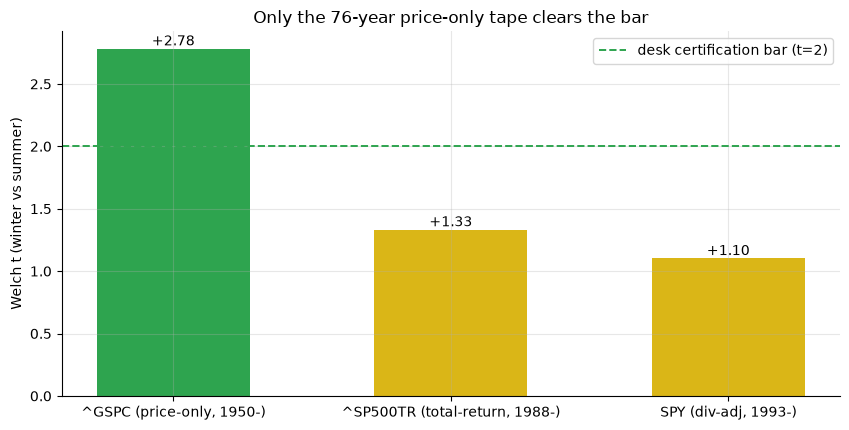

Welch t: {'^GSPC (price-only, 1950-)': 2.782332215681318, '^SP500TR (total-return, 1988-)': 1.332843022009182, 'SPY (div-adj, 1993-)': 1.1023591822548187}


In [3]:
if HAVE_REAL:
    ts = [stats[k]['welch_t'] for k in stats]
else:
    ts = [R['gspc']['welch'], R['sp500tr']['welch'], R['spy']['welch']]
fig, ax = plt.subplots(figsize=(8.6, 4.4))
cols = [GREEN if t >= 2 else AMBER for t in ts]
ax.bar(labels, ts, color=cols, width=.55)
ax.axhline(2, ls='--', c=GREEN, lw=1.4, label='desk certification bar (t=2)')
for i, v in enumerate(ts): ax.annotate(f'{v:+.2f}', (i, v), ha='center', va='bottom')
ax.set_ylabel('Welch t (winter vs summer)')
ax.set_title('Only the 76-year price-only tape clears the bar')
ax.legend(); plt.tight_layout(); plt.show()
print('Welch t:', dict(zip(labels, ts)))

The deep 76-year tape (**t = +2.78**) clears our bar. The two modern tapes that actually include dividends — the ones that describe what you'd really earn — sit at **t = +1.33** and **t = +1.10**: positive, same direction, but **not certified**. That's an honest "maybe, mostly."

**So what's driving even the strong result?** A few famous autumns:

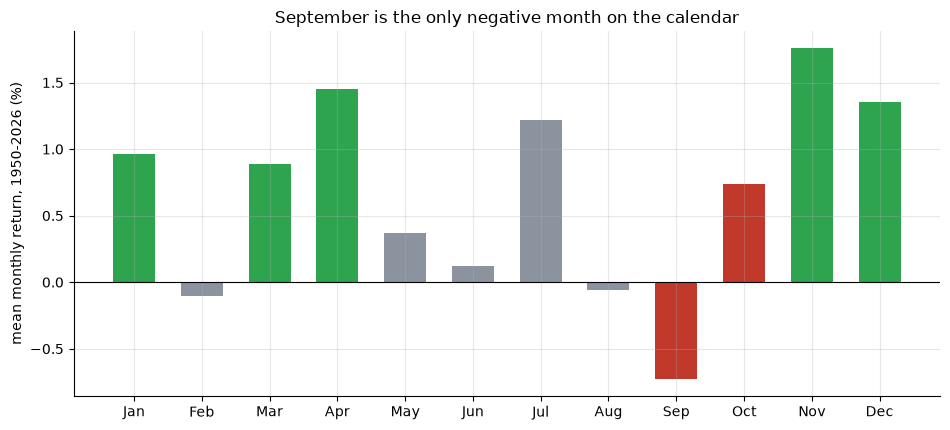

gap before trimming: +0.77%/mo (t=+2.78)
gap after dropping the 10 worst Sep/Oct months: +0.50%/mo (t=+1.88)


In [4]:
months = list(R['by_month'].keys())
vals = list(R['by_month'].values())
fig, ax = plt.subplots(figsize=(9.6, 4.4))
cols = [RED if m in ('Sep', 'Oct') else (GREEN if v > 0 and m not in ('May','Jun','Jul','Aug','Sep','Oct') else GREY) for m, v in zip(months, vals)]
ax.bar(months, vals, color=cols, width=.62)
ax.axhline(0, c='k', lw=.8)
ax.set_ylabel('mean monthly return, 1950-2026 (%)')
ax.set_title('September is the only negative month on the calendar')
plt.tight_layout(); plt.show()
print('gap before trimming: +0.77%/mo (t=+2.78)')
print('gap after dropping the 10 worst Sep/Oct months: +0.50%/mo (t=+1.88)')

September is the *only* month with a negative 76-year average. Pull out just the **10 worst Septembers and Octobers** (10/917 months — about **1%** of the entire sample: 1987's crash, 2008's crash, a handful of quieter bad years) and the winter-summer gap shrinks by **35%**, and the significance **disappears** (t = 2.78 → 1.88). A meaningful chunk of "sell in May" is really "avoid a short list of famous crashes," dressed up as a smooth six-month pattern.

**Finally — does the actual trade pay you?**

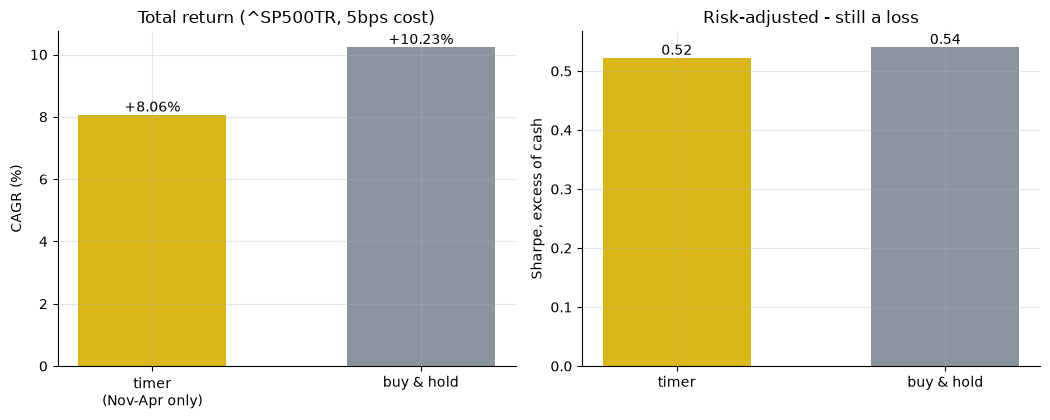

timer CAGR +8.06% vs buy&hold +10.23%  |  Sharpe 0.52 vs 0.54


In [5]:
if HAVE_REAL:
    r = st.halloween_timer(MM['sp500tr'], MM['irx_pct'], cost_bps=5.0)
    cagr, bh_cagr = r['cagr_pct'], r['bh_cagr_pct']
    sh, bh_sh = r['sharpe_excess'], r['bh_sharpe_excess']
else:
    cagr, bh_cagr = R['timer_tr'][5][0], R['timer_tr'][5][1]
    sh, bh_sh = R['timer_tr'][5][2], R['timer_tr'][5][3]
fig, (a1, a2) = plt.subplots(1, 2, figsize=(10.6, 4.3))
a1.bar(['timer\n(Nov-Apr only)', 'buy & hold'], [cagr, bh_cagr], color=[AMBER, GREY], width=.55)
for i, v in enumerate([cagr, bh_cagr]): a1.annotate(f'{v:+.2f}%', (i, v), ha='center', va='bottom')
a1.set_ylabel('CAGR (%)'); a1.set_title('Total return (^SP500TR, 5bps cost)')
a2.bar(['timer', 'buy & hold'], [sh, bh_sh], color=[AMBER, GREY], width=.55)
for i, v in enumerate([sh, bh_sh]): a2.annotate(f'{v:.2f}', (i, v), ha='center', va='bottom')
a2.set_ylabel('Sharpe, excess of cash'); a2.set_title('Risk-adjusted - still a loss')
plt.tight_layout(); plt.show()
print(f'timer CAGR {cagr:+.2f}% vs buy&hold {bh_cagr:+.2f}%  |  Sharpe {sh:.2f} vs {bh_sh:.2f}')

The timer **loses** — on plain return *and* on a risk-adjusted basis. Why? Because summer isn't a dangerous, break-even season to be avoided — it's a **smaller but positive** one. Sitting in cash for six months a year gives up real money, and the lower volatility you get in exchange isn't enough to make up for it once you compare like-for-like (excess of the same cash rate on both sides).

> ⚠️ One trap we found and avoided: run the same timer on the **price-only** ^GSPC tape (no dividends) and it looks like a *winner*. That's an illusion — buy-and-hold there is missing dividends for all twelve months, while the timer only misses six (it swaps the other six for a real cash yield). Put dividends back in (SPY, ^SP500TR) and the advantage reverses. Always compare like-for-like.

## 5 · The verdict

- **Signal — Weak.** Real over 76 years of deep, price-only history (*t* = +2.78) but **not certified** on the modern dividend-inclusive tape that actually matters for a portfolio (*t* = +1.10). Direction agrees everywhere; certainty doesn't.
- **Tradability — Mirage.** A cash-in-summer timer loses to buy-and-hold on both raw return and risk-adjusted return, because summer pays positive money.
- **"Driven by a handful of bad autumns"? — Confirmed.** About 1% of the months (ten crash-adjacent Septembers/Octobers) explain over a third of the gap and flip the deep-history significance off entirely when removed.

## 6 · Going further 🚪

- **The general lesson: a durable pattern isn't automatically a trade.** "Sell in May" is one of the most replicated calendar effects in finance, and it *still* loses to buy-and-hold once you charge it against a positive alternative. Statistical significance and economic value are two different questions.
- **Where this could get interesting**: testing the seasonal on markets/decades with genuinely negative or flat summers (some emerging markets, some pre-1950 eras) where the trade-off might tip the other way.
- **Sibling study:** [55-summer-lull](../../55-summer-lull/) reaches a compatible verdict on a single blended tape; this study shows *why* the tapes disagree and *how much* of the effect is a few famous autumns.

*Think the timer can be saved? Show a version that beats buy-and-hold on **excess-of-cash Sharpe**, after real costs, on the dividend-inclusive tape — then we'll talk.*